In [1]:
from run_main import run
import json
import pandas as pd
from IPython.display import Image, JSON, display
import helper_funcs as hf

Start with the worm model we already optimized for forward locomotion:

In [2]:
indir = 'example_W2D18L'
outdir = indir + "_CO2out"
pfolder = 'notebooks'
inputFolderName = pfolder + "/" + indir
outputFolderName = pfolder + "/" + outdir

Delete the output folder if necessary

In [3]:
hf.delete_subfolder_directory(pfolder, outdir)

True

Load the json configuration file from the optimized worm model.

In [4]:
json_data = hf.get_worm_json(inputFolderName)

The first thing to do is remove all the existing 'evotags' do stop further optimization of those forward locomotion parameters. The `delete_all_evotags(json_data)` function creates and returns a new copy of the supplied JSON dictionary with all evolutionary-tag information removed.

In [5]:
json_data = hf.delete_all_evotags(json_data)

Add a simple linearly decreasing concentration environment, with peak at the origin and gradient 0.5. The `environments` object defines one or more spatial chemical environments that sensors can monitor. Each environment has a unique `name`, a source location given by `x_center` and `y_center`, and a `grad_steep` value controlling how quickly concentration changes with distance. Sensors select an environment by referencing its name. Multiple sensors may share the same environment.

In [6]:
json_data=hf.add_environment(json_data, "salt_environment")
print('environments: ' + json.dumps(json_data['environments'], indent=2))

environments: {
  "salt_environment": {
    "name": {
      "value": "salt_environment"
    },
    "x_center": {
      "value": 0.0
    },
    "y_center": {
      "value": 0.0
    },
    "grad_steep": {
      "value": 0.5
    }
  }
}


Add a simple sensor of this environment. The sensor detects whether environmental concentration at the worm’s head is increasing or decreasing. It compares a recent average over `sensor_n` seconds with an earlier average over `sensor_m` seconds. `output_1` represents increasing concentration, while `output_2` represents decreasing concentration. The `weights` connect these outputs to nervous-system cells, and `environment` selects the sensed environment.

In [7]:
json_data=hf.add_sensor(json_data, "salt_environment")
print('sensors: ' + json.dumps(json_data['sensors'], indent=2))

sensors: {
  "sensor_1": {
    "environment": {
      "value": "salt_environment"
    },
    "sensor_m": {
      "value": 2.0
    },
    "sensor_n": {
      "value": 2.0
    },
    "outputs": {
      "message": "Available sensor output names for sensor-to-cell connections",
      "value": [
        {
          "name": "output_1",
          "description": "Positive change in sensed concentration (present average above past average)"
        },
        {
          "name": "output_2",
          "description": "Negative change in sensed concentration (past average above present average)"
        }
      ]
    },
    "weights": {
      "message": "Weights from sensor outputs to Nervous System cells",
      "value": []
    }
  }
}


We wish to make the sensor averaging timescales optimizable. The `add_evotag` function makes any numeric JSON parameter available for optimization by the genetic algorithm. The `keys` list identifies the parameter’s location, such as `["sensors", "sensor_1", "sensor_m"]`. It assigns a unique generated evotag unless a name is supplied, then creates a corresponding active entry in `evolvable_ranges`. Appropriate default optimization limits are selected according to the parameter type. The function returns a modified copy of the JSON dictionary.

In [8]:
keys =["sensors", "sensor_1", "sensor_m"]
json_data=hf.add_evotag(json_data, keys )
keys =["sensors", "sensor_1", "sensor_n"]
json_data=hf.add_evotag(json_data, keys )
print('sensors: ' + json.dumps(json_data['sensors'], indent=2))

sensors: {
  "sensor_1": {
    "environment": {
      "value": "salt_environment"
    },
    "sensor_m": {
      "value": 2.0,
      "evotag": "sensors_sensor_1_sensor_m_0"
    },
    "sensor_n": {
      "value": 2.0,
      "evotag": "sensors_sensor_1_sensor_n_0"
    },
    "outputs": {
      "message": "Available sensor output names for sensor-to-cell connections",
      "value": [
        {
          "name": "output_1",
          "description": "Positive change in sensed concentration (present average above past average)"
        },
        {
          "name": "output_2",
          "description": "Negative change in sensed concentration (past average above present average)"
        }
      ]
    },
    "weights": {
      "message": "Weights from sensor outputs to Nervous System cells",
      "value": []
    }
  }
}


Next we add a new random network for the sensor to connect to. The `add_random_cell_network` function adds a specified number of new interneurons to the JSON nervous system and returns the updated JSON together with their names. Cells are named `Cell_1`, `Cell_2`, and so on, skipping names already in use. Every directed pair of new cells is given a chemical connection with the requested probability, with weights sampled uniformly between `-1` and `1`; reciprocal connections may occur independently. The optional `random_seed` makes the generated network reproducible. The new network is initially isolated from all pre-existing cells. Here we add a fully connected network of size four with connection probability unity.

In [9]:
random_seed = 187566

In [10]:
json_data, cell_names=hf.add_random_cell_network(json_data, 4, 1, random_seed=random_seed)
print(cell_names)
print(cell_names[0] +' :' + json.dumps(json_data['nervous_system']['cells'][cell_names[0]], indent=2))

['Cell_1', 'Cell_2', 'Cell_3', 'Cell_4']
Cell_1 :{
  "bias": {
    "value": 0.0
  },
  "cell_class": {
    "value": "interneuron"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.0
  },
  "tau": {
    "value": 1.0
  }
}


We can examine the connections between the newly added cells. The `get_chemical_connection` function searches for a directed chemical connection from `from_cell` to `to_cell`. The get `get_electrical_connection` function searches for an electrical connection between two cells in either stored order because electrical connections are reciprocal. Both return a copy of the complete connection JSON object when found, including its weight and evotag, or `None` when absent. Neither function modifies the supplied JSON dictionary.

In [11]:
for from_cell in cell_names:
    for to_cell in cell_names:
        chem_con = hf.get_chemical_connection(json_data, from_cell, to_cell)
        elec_con = hf.get_electrical_connection(json_data, from_cell, to_cell)
        if chem_con is not None: print('Chem con: ' + json.dumps(chem_con))
        if elec_con is not None: print('Elec con: ' + json.dumps(elec_con))

Chem con: {"from": "Cell_1", "to": "Cell_2", "weight": {"value": -0.46581838011019716}}
Chem con: {"from": "Cell_1", "to": "Cell_3", "weight": {"value": -0.6532378528263765}}
Chem con: {"from": "Cell_1", "to": "Cell_4", "weight": {"value": 0.011128255426831712}}
Chem con: {"from": "Cell_2", "to": "Cell_1", "weight": {"value": -0.6893389395301461}}
Chem con: {"from": "Cell_2", "to": "Cell_3", "weight": {"value": -0.5714996102227492}}
Chem con: {"from": "Cell_2", "to": "Cell_4", "weight": {"value": 0.20998238562897464}}
Chem con: {"from": "Cell_3", "to": "Cell_1", "weight": {"value": 0.09989078954928265}}
Chem con: {"from": "Cell_3", "to": "Cell_2", "weight": {"value": -0.24135574171201868}}
Chem con: {"from": "Cell_3", "to": "Cell_4", "weight": {"value": -0.5528849698543961}}
Chem con: {"from": "Cell_4", "to": "Cell_1", "weight": {"value": -0.4424871339803247}}
Chem con: {"from": "Cell_4", "to": "Cell_2", "weight": {"value": -0.43997975706815273}}
Chem con: {"from": "Cell_4", "to": "Cel

We also want to make these connections optimizable. The `add_chemical_connection_evotag` function makes the weight of an existing directed chemical connection optimizable by the genetic algorithm. It takes the JSON dictionary and the names of the source and destination cells, then adds a unique evotag to the matching connection weight. A corresponding active entry with suitable default limits is added to `evolvable_ranges`; a custom evotag name may also be supplied. The function returns a modified copy of the JSON and raises an error if the connection does not exist.

In [12]:
for from_cell in cell_names:
    for to_cell in cell_names:
        if from_cell != to_cell:
            json_data = hf.add_chemical_connection_evotag(json_data, from_cell, to_cell)
            chem_con = hf.get_chemical_connection(json_data, from_cell, to_cell)
            if chem_con is not None: print('Chem con: ' + json.dumps(chem_con))

Chem con: {"from": "Cell_1", "to": "Cell_2", "weight": {"value": -0.46581838011019716, "evotag": "ns_chemcons_0"}}
Chem con: {"from": "Cell_1", "to": "Cell_3", "weight": {"value": -0.6532378528263765, "evotag": "ns_chemcons_1"}}
Chem con: {"from": "Cell_1", "to": "Cell_4", "weight": {"value": 0.011128255426831712, "evotag": "ns_chemcons_2"}}
Chem con: {"from": "Cell_2", "to": "Cell_1", "weight": {"value": -0.6893389395301461, "evotag": "ns_chemcons_3"}}
Chem con: {"from": "Cell_2", "to": "Cell_3", "weight": {"value": -0.5714996102227492, "evotag": "ns_chemcons_4"}}
Chem con: {"from": "Cell_2", "to": "Cell_4", "weight": {"value": 0.20998238562897464, "evotag": "ns_chemcons_5"}}
Chem con: {"from": "Cell_3", "to": "Cell_1", "weight": {"value": 0.09989078954928265, "evotag": "ns_chemcons_6"}}
Chem con: {"from": "Cell_3", "to": "Cell_2", "weight": {"value": -0.24135574171201868, "evotag": "ns_chemcons_7"}}
Chem con: {"from": "Cell_3", "to": "Cell_4", "weight": {"value": -0.5528849698543961,

We also want to make some cell parameters optimizable by the genetic algorithm. The `add_cell_parameter_evotag` function makes a specified nervous-system cell parameter optimizable by the genetic algorithm. It takes the JSON dictionary, cell name, and parameter name, such as `tau` or `bias`. The function adds a unique evotag to that parameter and creates an active entry in `evolvable_ranges` with suitable default limits. A custom evotag name can optionally be supplied. It returns a modified copy of the JSON dictionary.

In [13]:
evolvable_pars = ["tau", "bias"]
for cell_name in cell_names:
    for evolvable_par in evolvable_pars:
        json_data=hf.add_cell_parameter_evotag(json_data, cell_name, evolvable_par)
print(cell_names[0] +' :' + json.dumps(json_data['nervous_system']['cells'][cell_names[0]], indent=2))

Cell_1 :{
  "bias": {
    "value": 0.0,
    "evotag": "ns_cells_bias_0"
  },
  "cell_class": {
    "value": "interneuron"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.0
  },
  "tau": {
    "value": 1.0,
    "evotag": "ns_cells_tau_0"
  }
}


We also need to connections from the sensor to the added network of interneurons, and also make these optimizable. Here we add connections from both sensor outputs to all four interneuron cells. The `add_sensor_connection` function connects a named sensor output, such as `output_1` or `output_2`, to a nervous-system cell. It adds the connection to the sensor’s `weights` list with a configurable weight, leaving an existing connection unchanged. When `make_evolvable=True`, the weight receives a unique evotag and a corresponding entry is added to `evolvable_ranges`. The function returns a modified copy of the JSON dictionary.

In [14]:
for cell_name in cell_names:
    json_data=hf.add_sensor_connection(json_data,"sensor_1",
                         "output_1",cell_name ,make_evolvable=True)
    json_data=hf.add_sensor_connection(json_data,"sensor_1",
                         "output_2",cell_name ,make_evolvable=True)
print('sensors: ' + json.dumps(json_data['sensors'], indent=2))

sensors: {
  "sensor_1": {
    "environment": {
      "value": "salt_environment"
    },
    "sensor_m": {
      "value": 2.0,
      "evotag": "sensors_sensor_1_sensor_m_0"
    },
    "sensor_n": {
      "value": 2.0,
      "evotag": "sensors_sensor_1_sensor_n_0"
    },
    "outputs": {
      "message": "Available sensor output names for sensor-to-cell connections",
      "value": [
        {
          "name": "output_1",
          "description": "Positive change in sensed concentration (present average above past average)"
        },
        {
          "name": "output_2",
          "description": "Negative change in sensed concentration (past average above present average)"
        }
      ]
    },
    "weights": {
      "message": "Weights from sensor outputs to Nervous System cells",
      "value": [
        {
          "from_output": 1,
          "to_cell": "Cell_1",
          "weight": {
            "value": 1.0,
            "evotag": "sensors_sensor_1_weights_weight_0"
         

Finally we want to add connections from the new interneuron network to the rest of the nervous system. Here we add two connections, each from a given interneuron to a head cell. We also make these new connections optimizable. The `add_cell_connection` function adds a directed chemical connection from one nervous-system cell to another. The connection is assigned the supplied weight or, if none is provided, a random weight uniformly distributed between `-1` and `1`. An optional random seed makes this weight reproducible. If the connection already exists, it is left unchanged. The function returns a modified copy of the JSON dictionary.

In [15]:
head_cells = ["SMDD_0","SMDV_0"]
for (from_cell, head_cell) in zip(cell_names[0:2],head_cells):
    json_data=hf.add_cell_connection(json_data, from_cell, head_cell, random_seed=random_seed)
    json_data=hf.add_chemical_connection_evotag(json_data, from_cell, head_cell)
    chem_con = hf.get_chemical_connection(json_data, from_cell, head_cell)
    if chem_con is not None: print('Chem con: ' + json.dumps(chem_con))

Chem con: {"from": "Cell_1", "to": "SMDD_0", "weight": {"value": -0.8236176934390114, "evotag": "ns_chemcons_12"}}
Chem con: {"from": "Cell_2", "to": "SMDV_0", "weight": {"value": -0.8236176934390114, "evotag": "ns_chemcons_13"}}


The upper and lower limits for the optimizable parameters are in the 'evolvable_ranges' json field. These have been set from defaults, but can be changed if necessary. Here we leave them as is. 

In [16]:
print('evolvable_ranges: ' + json.dumps(json_data['evolvable_ranges'], indent=2))

evolvable_ranges: {
  "sensors_sensor_1_sensor_m_0": {
    "active": true,
    "lower_limit": 0.1,
    "name": "sensors_sensor_1_sensor_m",
    "upper_limit": 4.2
  },
  "sensors_sensor_1_sensor_n_0": {
    "active": true,
    "lower_limit": 0.1,
    "name": "sensors_sensor_1_sensor_n",
    "upper_limit": 4.2
  },
  "ns_chemcons_0": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_chemcons",
    "upper_limit": 15.0
  },
  "ns_chemcons_1": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_chemcons",
    "upper_limit": 15.0
  },
  "ns_chemcons_2": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_chemcons",
    "upper_limit": 15.0
  },
  "ns_chemcons_3": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_chemcons",
    "upper_limit": 15.0
  },
  "ns_chemcons_4": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_chemcons",
    "upper_limit": 15.0
  },
  "ns_chemcons_5": {
    "active": true,
    "lower_limit": -15.0,
  

Set the arguments for the optimization and subsequent simulation:

In [17]:
Pi = 3.1415926
args = dict(
    duration=50,
    transient=10,
    simduration=500,
    simtransient=0,
    maxGens=10,
    popSize=16,
    RandSeed=random_seed,
    modelName="W2DSR",
    modelFolder="Worm2D",
    outputFolderName=outputFolderName,
    reRand=True,
    doTestRun=True,
    doEvol=True,
    resetAgentBody=True,
    orient=Pi / 4,
    rotation=Pi / 4,
    doOrigSRInput=False,
    doOrigMuscInput=False,
    checkPointInterval=5,
    evo_type="EvoCO2",
    overwrite=True,
    doCPT=True
)

Previously we had used `evo_type="Evo18"`, which optimizes for locomotion in a forward direction. Now we change the optimization function. When `evo_type="EvoCO2"` is selected, the genetic algorithm optimizes the parameters marked by active evotags for chemotaxis toward the centre of the selected environment. Each candidate genotype is tested from four starting orientations: `0`, `π/2`, `π`, and `3π/2`, with the worm reinitialized for each test. After the transient period, fitness is calculated from the average head distance to the environment centre and the four results are averaged. `duration` specifies the length of time over which each individual is evaluated during evolution. `transient` specifies an initial settling period that runs before fitness is measured, allowing the nervous system and body dynamics to stabilise. The total runtime of each evolutionary evaluation is therefore `transient + duration`. The `resetAgentBody` determines whether the worm is repositioned before the simulation begins after the optimization. When enabled, the worm is placed `max_dist = 4.5` from the origin in the direction opposite `orient`. The `orient` parameter therefore controls its starting position around the environment, while `rotation` controls the angle through which the worm’s body is rotated about its head, determining its initial heading.

Make sure to save the modified json file to the output directory. We can also set the inputFolderName to carry over the fitness history.



Directory 'notebooks/example_W2D18L_CO2out' already exists and all the contents will be overwritten.
Input evolution history will not be copied because active evolvable_ranges evotags in notebooks/example_W2D18L_CO2out/worm_data_worm.json do not match evolved_used.
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json
Parameter reset_agent_body not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--reset_agent_body', '1', '--rotation', '0.78539815', '--orient', '0.78539815', '--do_test_run', '1', '-R', '187566', '--population_size', '16', '--duration', '50', '--transient', '10', '--max_generations', '10', '-sd', '500', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--folder', 'notebooks/example_W2D18L_CO2out', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCO2']
Starting Worm2D v0.1.0
jsonfile notebooks

/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: divide by zero encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: invalid value encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_3col.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_4col.png


/home/adam/miniconda3/envs/celoc_env/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_av.png
Saved plot image to: notebooks/example_W2D18L_CO2out/FitnessHist.png


/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: divide by zero encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: invalid value encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages.png
Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages_2.png
Finished!


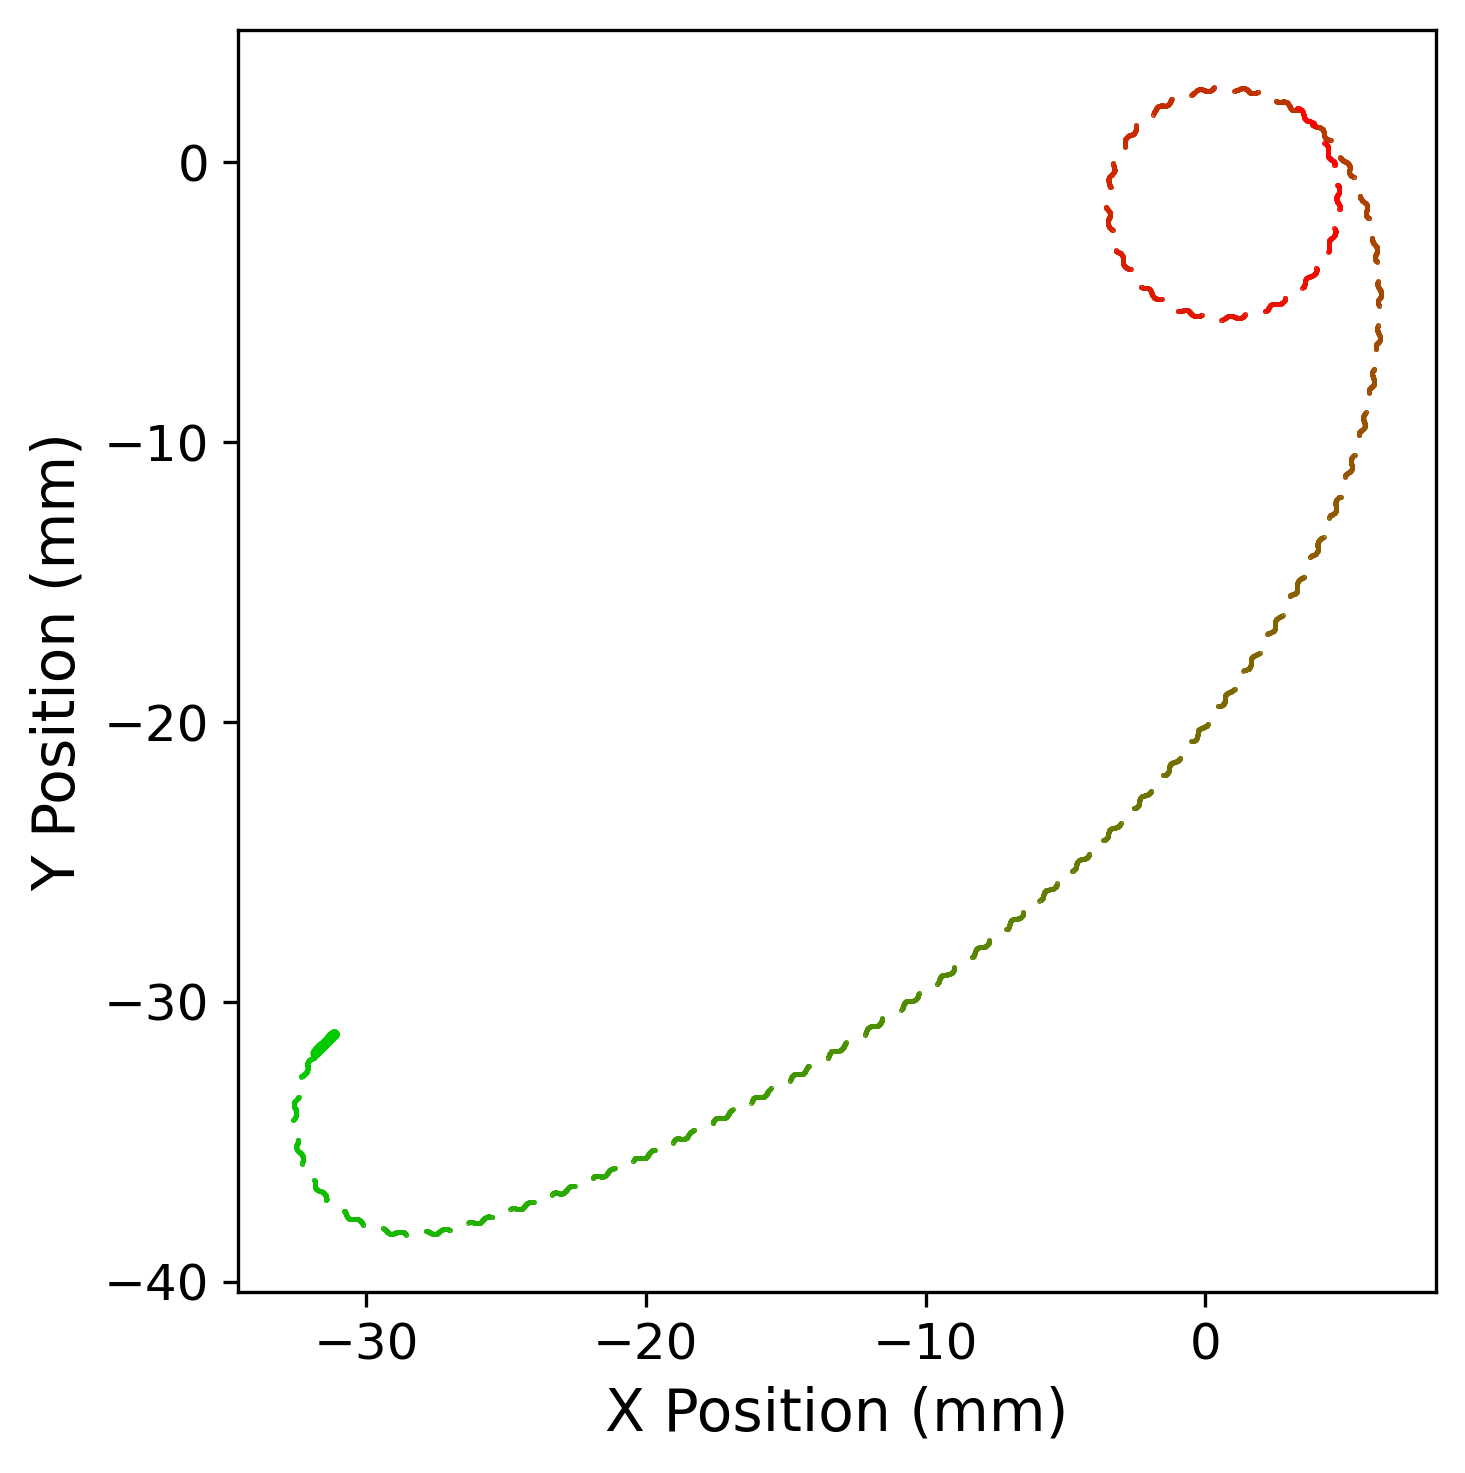

In [18]:
args['inputFolderName']=inputFolderName
hf.write_worm_json(outputFolderName, json_data)
run(**args)
Image(filename=outputFolderName + '/Motion.png')

We may need to optimize further. Make sure to unset the inputFolderName to continue from the configuration in the outputFolder and not to save the old json file. 

Directory 'notebooks/example_W2D18L_CO2out' already exists and all the contents will be overwritten.
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json
Parameter reset_agent_body not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--reset_agent_body', '1', '--rotation', '0.78539815', '--orient', '0.78539815', '--do_test_run', '1', '-R', '187566', '--population_size', '16', '--duration', '50', '--transient', '10', '--max_generations', '10', '-sd', '500', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--folder', 'notebooks/example_W2D18L_CO2out', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCO2']
Starting Worm2D v0.1.0
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_CO2out/search.cpt

/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: divide by zero encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: invalid value encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_3col.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_4col.png


/home/adam/miniconda3/envs/celoc_env/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_av.png
Saved plot image to: notebooks/example_W2D18L_CO2out/FitnessHist.png


/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: divide by zero encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: invalid value encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages.png
Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages_2.png
Finished!


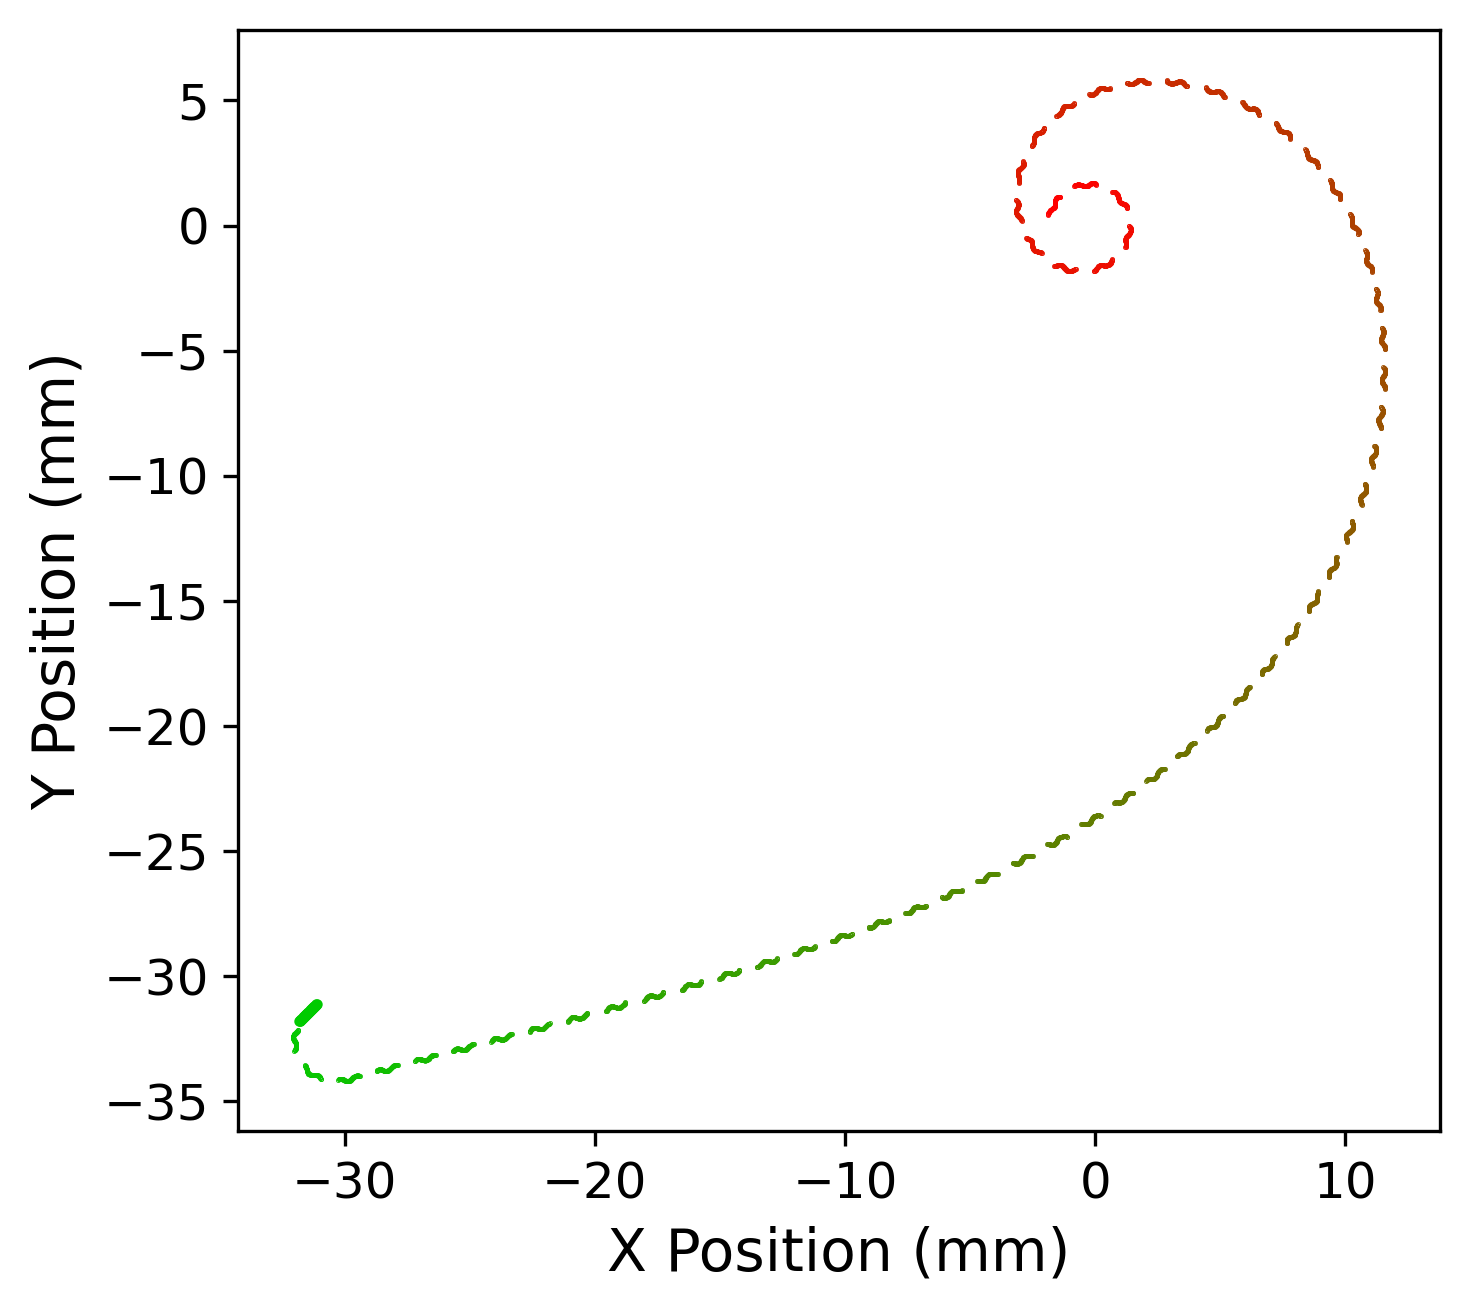

In [19]:
args['inputFolderName']=None
run(**args)
Image(filename=outputFolderName + '/Motion.png')

Directory 'notebooks/example_W2D18L_CO2out' already exists and all the contents will be overwritten.
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json
Parameter reset_agent_body not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--reset_agent_body', '1', '--rotation', '0.78539815', '--orient', '0.78539815', '--do_test_run', '1', '-R', '187566', '--population_size', '16', '--duration', '50', '--transient', '10', '--max_generations', '10', '-sd', '500', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--folder', 'notebooks/example_W2D18L_CO2out', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCO2']
Starting Worm2D v0.1.0
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_CO2out/search.cpt

/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: divide by zero encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: invalid value encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_3col.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_4col.png


/home/adam/miniconda3/envs/celoc_env/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_av.png
Saved plot image to: notebooks/example_W2D18L_CO2out/FitnessHist.png


/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: divide by zero encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: invalid value encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages.png
Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages_2.png
Finished!


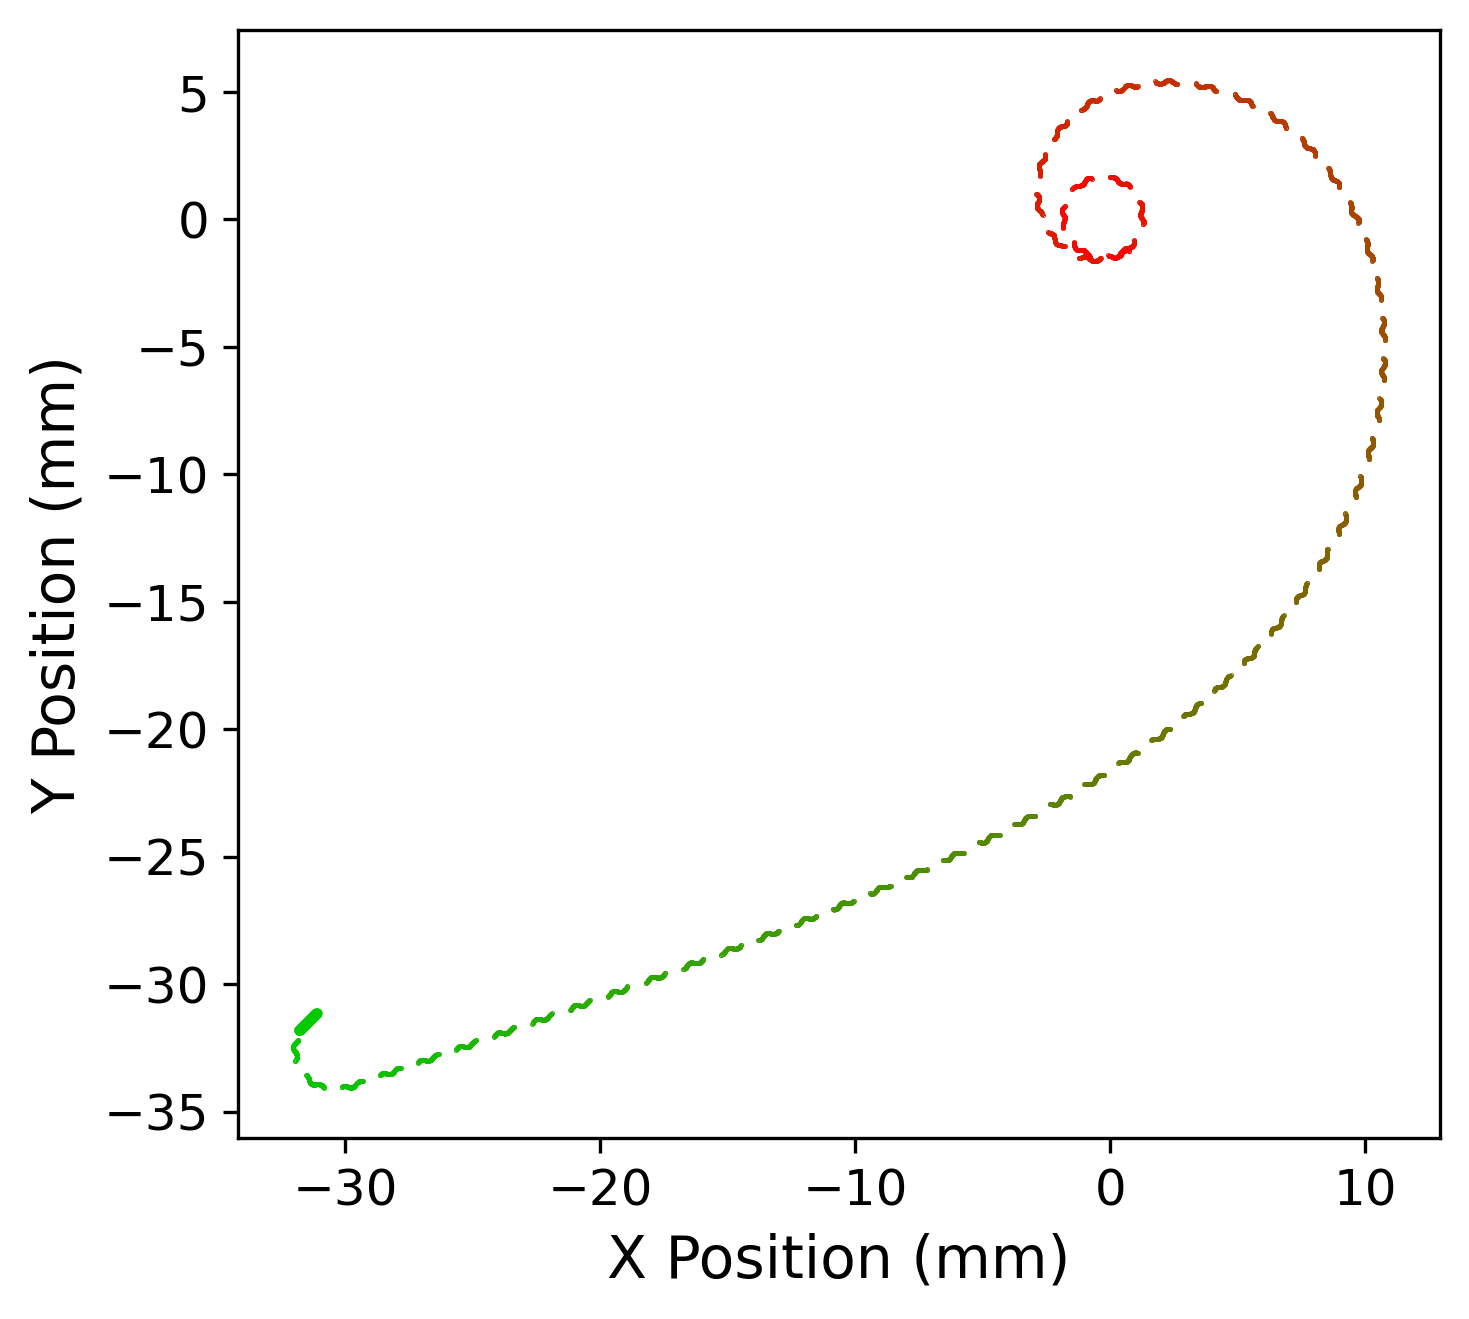

In [20]:
args['inputFolderName']=None
run(**args)
Image(filename=outputFolderName + '/Motion.png')

Directory 'notebooks/example_W2D18L_CO2out' already exists and all the contents will be overwritten.
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json
Parameter reset_agent_body not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--reset_agent_body', '1', '--rotation', '0.78539815', '--orient', '0.78539815', '--do_test_run', '1', '-R', '187566', '--population_size', '16', '--duration', '50', '--transient', '10', '--max_generations', '10', '-sd', '500', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--folder', 'notebooks/example_W2D18L_CO2out', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCO2']
Starting Worm2D v0.1.0
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_CO2out/search.cpt

/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: divide by zero encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: invalid value encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_3col.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_4col.png


/home/adam/miniconda3/envs/celoc_env/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_av.png
Saved plot image to: notebooks/example_W2D18L_CO2out/FitnessHist.png


/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: divide by zero encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: invalid value encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages.png
Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages_2.png
Finished!


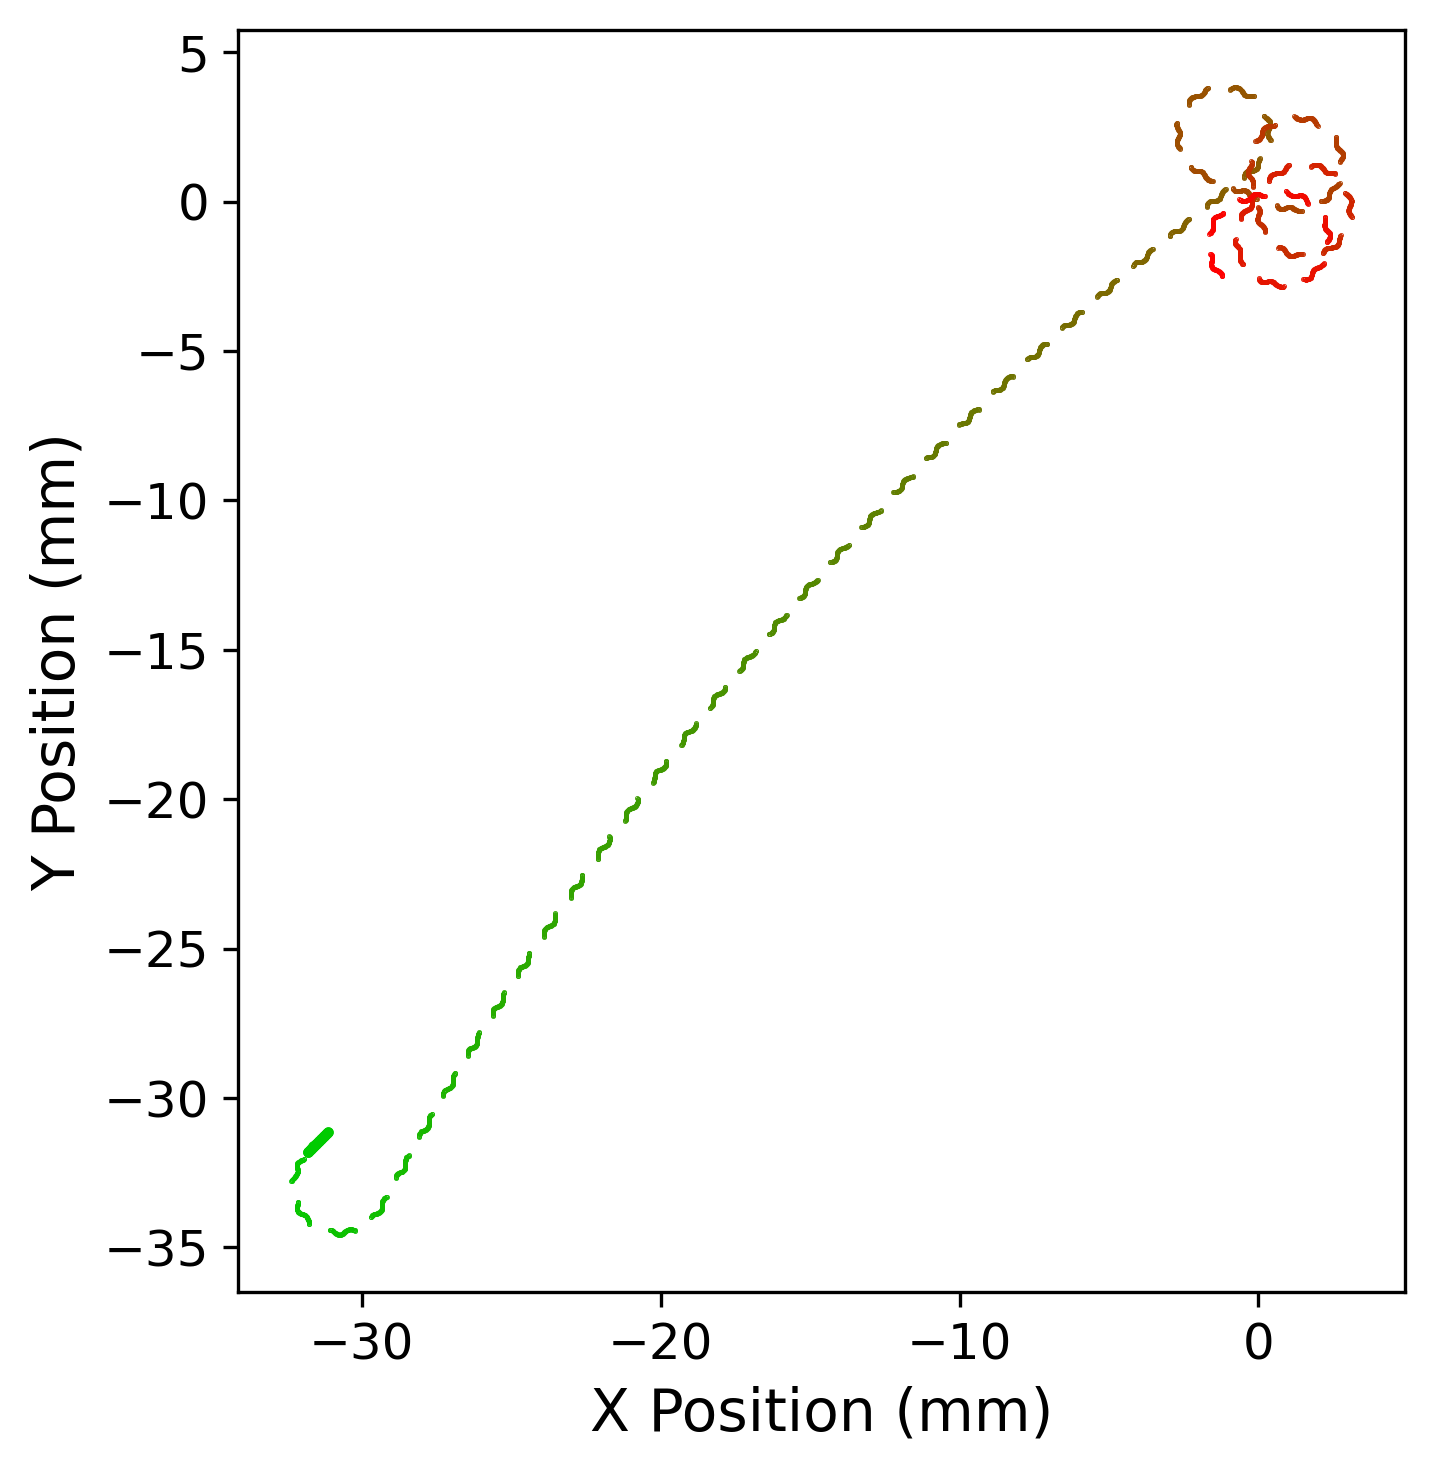

In [21]:
args['inputFolderName']=None
run(**args)
Image(filename=outputFolderName + '/Motion.png')

Directory 'notebooks/example_W2D18L_CO2out' already exists and all the contents will be overwritten.
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json
Parameter reset_agent_body not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--reset_agent_body', '1', '--rotation', '0.78539815', '--orient', '0.78539815', '--do_test_run', '1', '-R', '187566', '--population_size', '16', '--duration', '50', '--transient', '10', '--max_generations', '10', '-sd', '500', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--folder', 'notebooks/example_W2D18L_CO2out', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCO2']
Starting Worm2D v0.1.0
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_CO2out/search.cpt

/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: divide by zero encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: invalid value encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_3col.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_4col.png


/home/adam/miniconda3/envs/celoc_env/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_av.png
Saved plot image to: notebooks/example_W2D18L_CO2out/FitnessHist.png


/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: divide by zero encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: invalid value encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages.png
Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages_2.png
Finished!


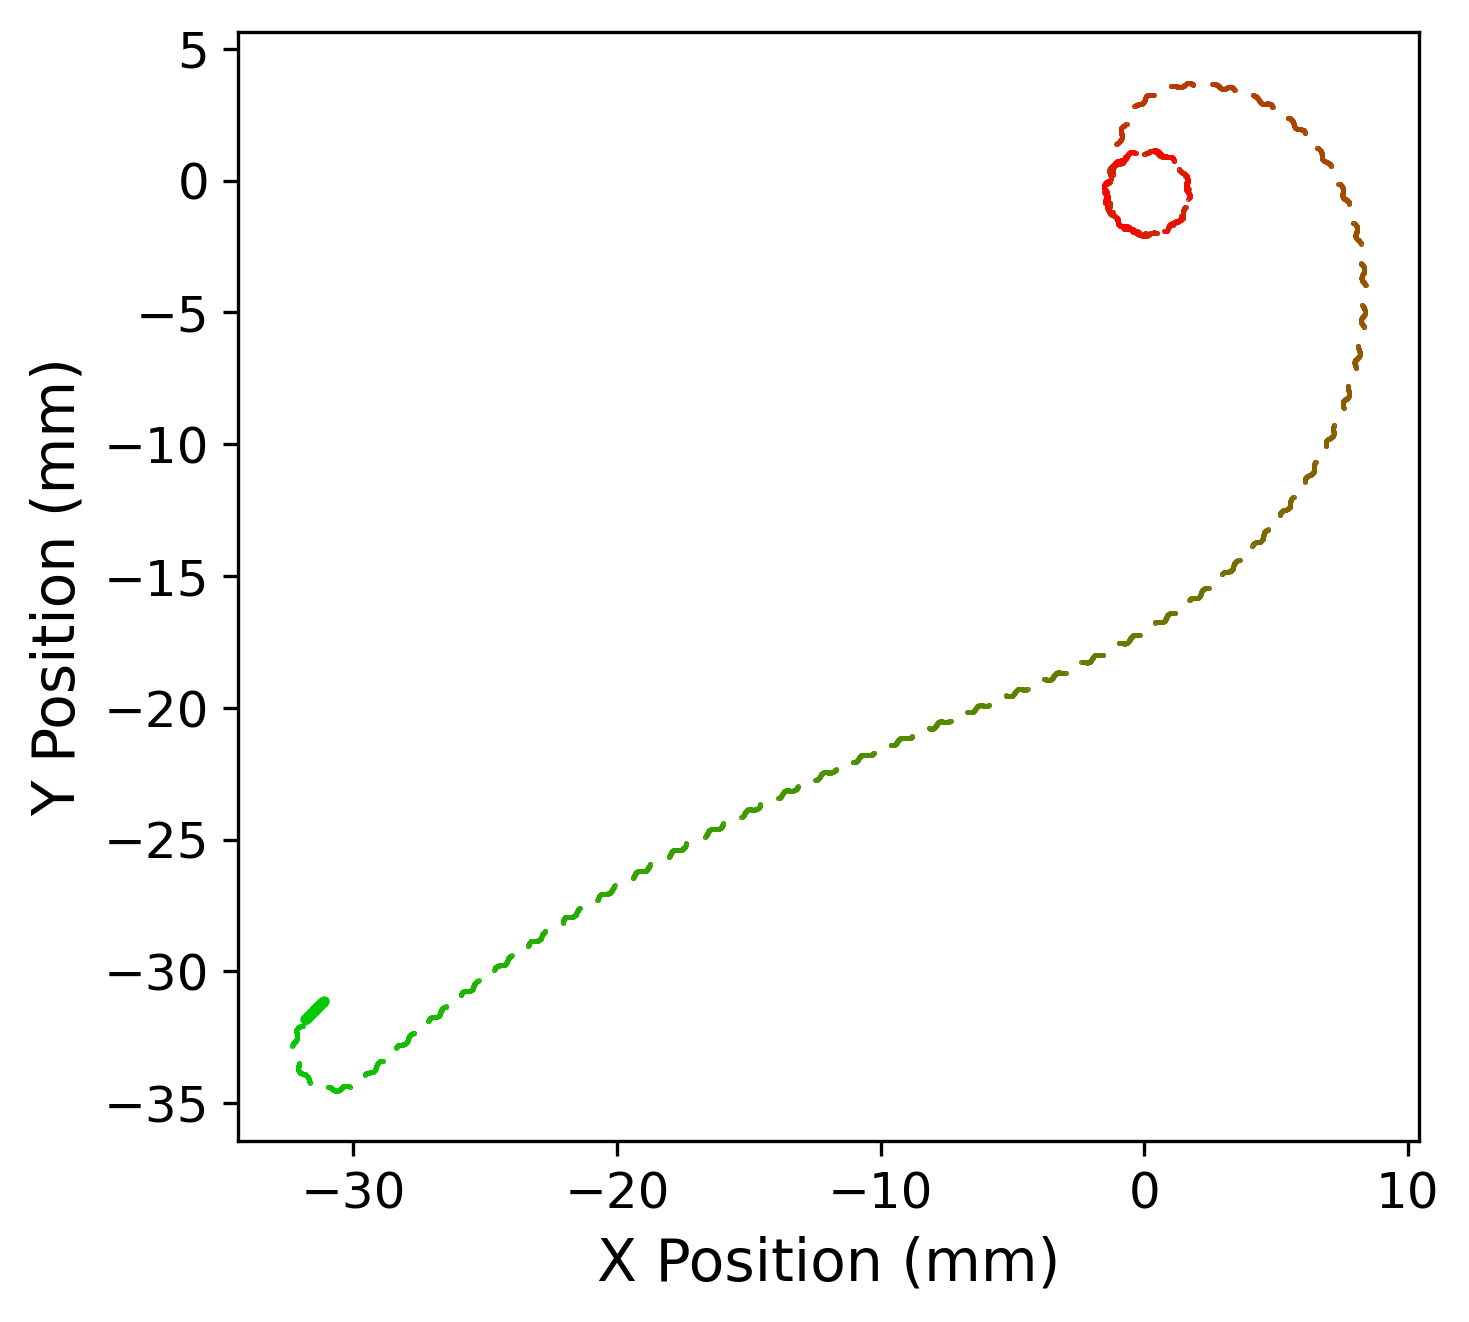

In [22]:
args['inputFolderName']=None
run(**args)
Image(filename=outputFolderName + '/Motion.png')

Directory 'notebooks/example_W2D18L_CO2out' already exists and all the contents will be overwritten.
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json
Parameter reset_agent_body not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--reset_agent_body', '1', '--rotation', '0.78539815', '--orient', '0.78539815', '--do_test_run', '1', '-R', '187566', '--population_size', '16', '--duration', '50', '--transient', '10', '--max_generations', '10', '-sd', '500', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--folder', 'notebooks/example_W2D18L_CO2out', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCO2']
Starting Worm2D v0.1.0
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_CO2out/search.cpt

/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: divide by zero encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: invalid value encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_3col.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_4col.png


/home/adam/miniconda3/envs/celoc_env/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_av.png
Saved plot image to: notebooks/example_W2D18L_CO2out/FitnessHist.png


/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: divide by zero encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: invalid value encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages.png
Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages_2.png
Finished!


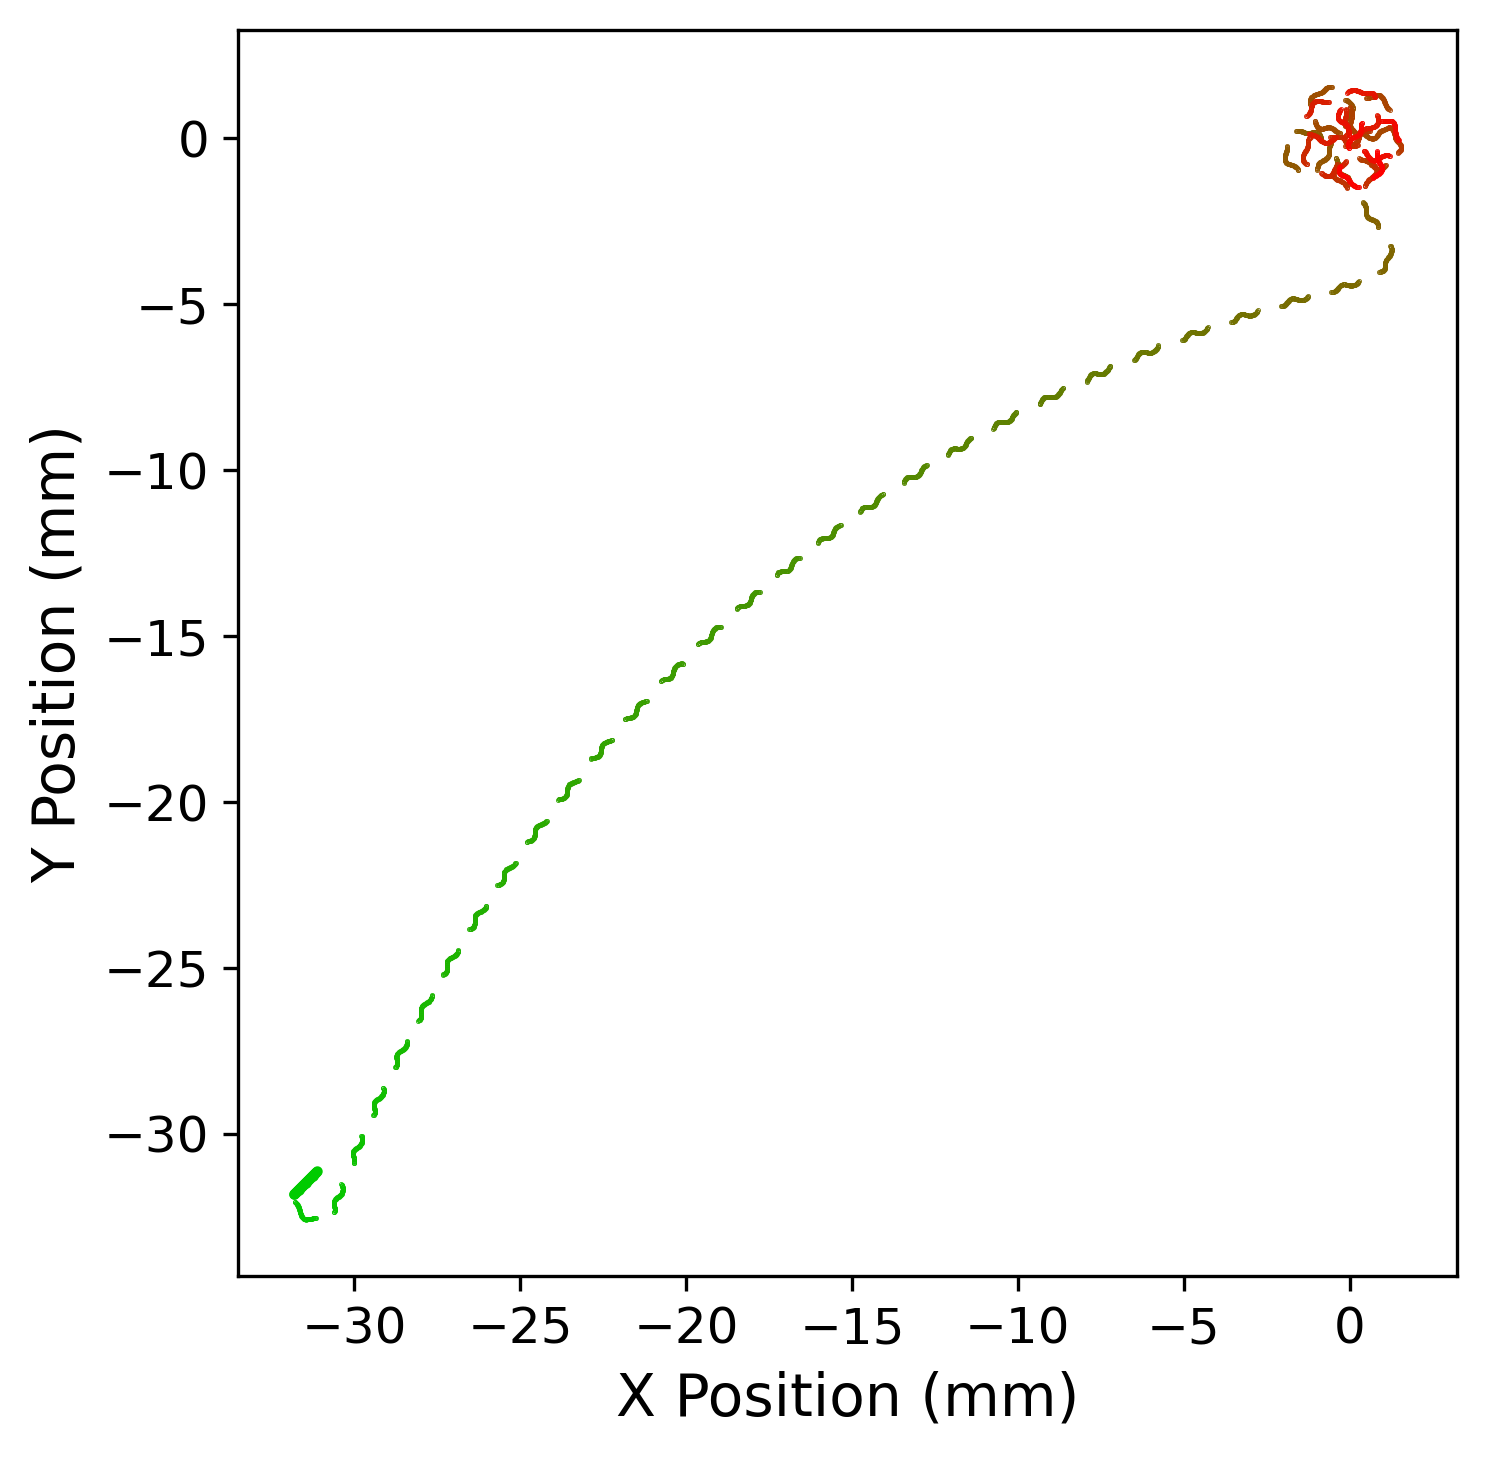

In [23]:
args['inputFolderName']=None
run(**args)
Image(filename=outputFolderName + '/Motion.png')

Directory 'notebooks/example_W2D18L_CO2out' already exists and all the contents will be overwritten.
Parameter do_orig_musc_input not found in worm_data.json
Parameter do_orig_sr_input not found in worm_data.json
Parameter reset_agent_body not found in worm_data.json

  Running Worm2D v0.1.0 with the following command:
['Worm2D/main_osc', '--do_orig_musc_input', '0', '--do_orig_sr_input', '0', '--reset_agent_body', '1', '--rotation', '0.78539815', '--orient', '0.78539815', '--do_test_run', '1', '-R', '187566', '--population_size', '16', '--duration', '50', '--transient', '10', '--max_generations', '10', '-sd', '500', '-st', '0', '--doevol', '1', '--checkpoint_interval', '5', '--folder', 'notebooks/example_W2D18L_CO2out', '--modelname', 'W2DSR', '-docpt', '1', '--evo_type', 'EvoCO2']
Starting Worm2D v0.1.0
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
jsonfile notebooks/example_W2D18L_CO2out/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_CO2out/search.cpt

/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: divide by zero encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:235: RuntimeWarning: invalid value encountered in divide
  evol_data_diff_1 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_3col.png
Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_legend_4col.png


/home/adam/miniconda3/envs/celoc_env/lib/python3.12/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Saved plot image to: notebooks/example_W2D18L_CO2out/EvoHist_av.png
Saved plot image to: notebooks/example_W2D18L_CO2out/FitnessHist.png


/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: divide by zero encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]
/home/adam/uclwork/CE_locomotion/load_data.py:312: RuntimeWarning: invalid value encountered in divide
  evol_data_full_diff0 = evol_data / evol_data[0]


Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages.png
Saved plot image to: notebooks/example_W2D18L_CO2out/Evolution_averages_2.png
Finished!


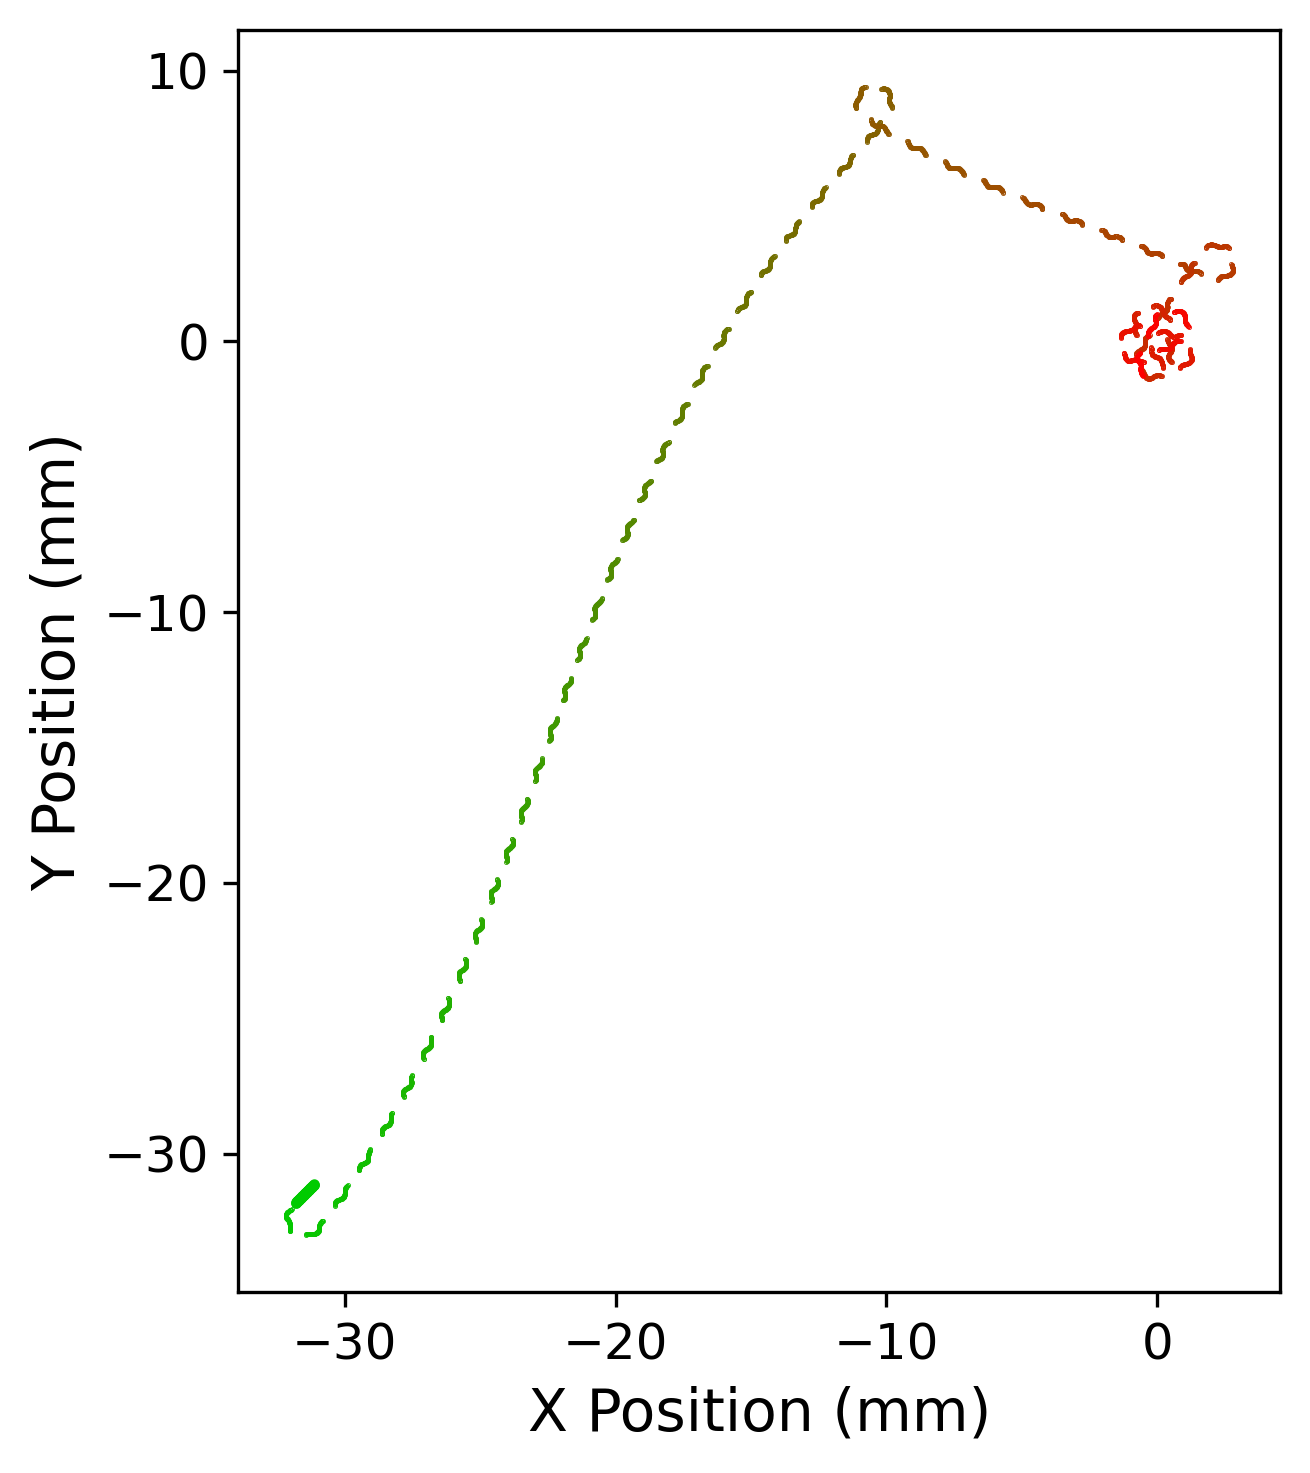

In [24]:
args['inputFolderName']=None
run(**args)
Image(filename=outputFolderName + '/Motion.png')